In [1]:
import importlib

import experiment
import experiment.config
import experiment.data
import experiment.rolling_forecast.runner

importlib.reload(experiment.config)
importlib.reload(experiment.data)
importlib.reload(experiment.rolling_forecast.runner)
importlib.reload(experiment)

from experiment import DatasetBuilder, ModelSpec, RollingForecastRunner, RunConfig


In [4]:
CSV_PATH = './data/33101.csv'
UNIQUE_ID = 'ZJ'

INPUT_SIZE = 96
HORIZON = 7
SPLIT_RATIO = (7, 1, 2)
SLIDING_STEP_SIZE = 1

USE_EXOG = True
# USE_EXOG = False

SAVE_PLOTS = True
RANDOM_SEED = 2026
EARLY_STOP_PATIENCE_STEPS = 7
VAL_CHECK_STEPS = 5
ML_EARLY_STOPPING_ROUNDS = 20
# Neural training/validation loss
# Options:
# - 'MAE'
# - 'MSE'
# - 'RMSE'
# - 'MAPE'
# - 'SMAPE'
# - 'HuberLoss'   optional params: {'delta': 1.0}
# - 'TukeyLoss'   optional params: {'c': 4.685, 'normalize': True}
# - 'MASE'        required params: {'seasonality': 7}
NEURAL_LOSS_NAME = 'MSE'
NEURAL_LOSS_PARAMS = {}
PLOT_FORECAST = True
PLOT_LOSS = True
SAVE_DIR = './artifacts'

prepared_dataset = DatasetBuilder.from_csv(
    csv_path=CSV_PATH,
    unique_id=UNIQUE_ID,
)

run_config = RunConfig(
    input_size=INPUT_SIZE,
    horizon=HORIZON,
    split_ratio=SPLIT_RATIO,
    sliding_step_size=SLIDING_STEP_SIZE,
    use_exog=USE_EXOG,
    save_plots=SAVE_PLOTS,
    random_seed=RANDOM_SEED,
    early_stop_patience_steps=EARLY_STOP_PATIENCE_STEPS,
    val_check_steps=VAL_CHECK_STEPS,
    ml_early_stopping_rounds=ML_EARLY_STOPPING_ROUNDS,
    neural_loss_name=NEURAL_LOSS_NAME,
    neural_loss_params=NEURAL_LOSS_PARAMS,
    save_dir=SAVE_DIR,
    plot_forecast=PLOT_FORECAST,
    plot_loss=PLOT_LOSS,
)

runner = RollingForecastRunner(
    prepared_dataset=prepared_dataset,
    run_config=run_config,
)

prepared_dataset.futr_exog

['weather_code_wmo_code',
 'temperature_2m_max_degC',
 'temperature_2m_mean_degC',
 'temperature_2m_min_degC',
 'apparent_temperature_max_degC',
 'apparent_temperature_mean_degC',
 'apparent_temperature_min_degC',
 'sunrise_iso8601',
 'sunset_iso8601',
 'daylight_duration_s',
 'sunshine_duration_s',
 'uv_index_clear_sky_max_',
 'uv_index_max_',
 'rain_sum_mm',
 'showers_sum_mm',
 'snowfall_sum_cm',
 'precipitation_sum_mm',
 'precipitation_hours_h',
 'et0_fao_evapotranspiration_mm',
 'shortwave_radiation_sum_MJ_m_square',
 'wind_direction_10m_dominant_deg',
 'wind_gusts_10m_max_km_h',
 'wind_speed_10m_max_km_h',
 'power_lag2',
 'mean_lag2',
 'median_lag2',
 'std_lag2',
 'min_lag2',
 'range_lag2',
 'Q1_lag2',
 'Q3_lag2',
 'var_lag2',
 'OT_lag2',
 'OT_lag7',
 'sunrise_iso8601_day_sin',
 'sunrise_iso8601_day_cos',
 'sunset_iso8601_day_sin',
 'sunset_iso8601_day_cos',
 'daylight_duration_s_sin',
 'daylight_duration_s_cos',
 'sunshine_duration_s_sin',
 'sunshine_duration_s_cos',
 'precipitat

Seed set to 2026
Seed set to 2026


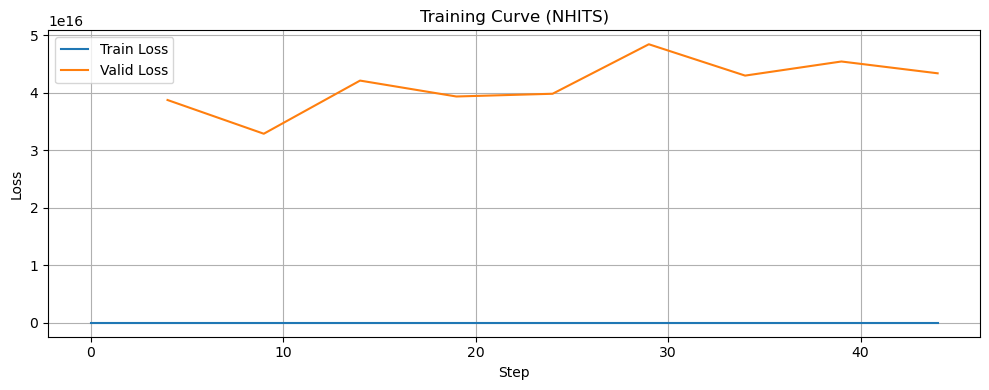

Seed set to 2026


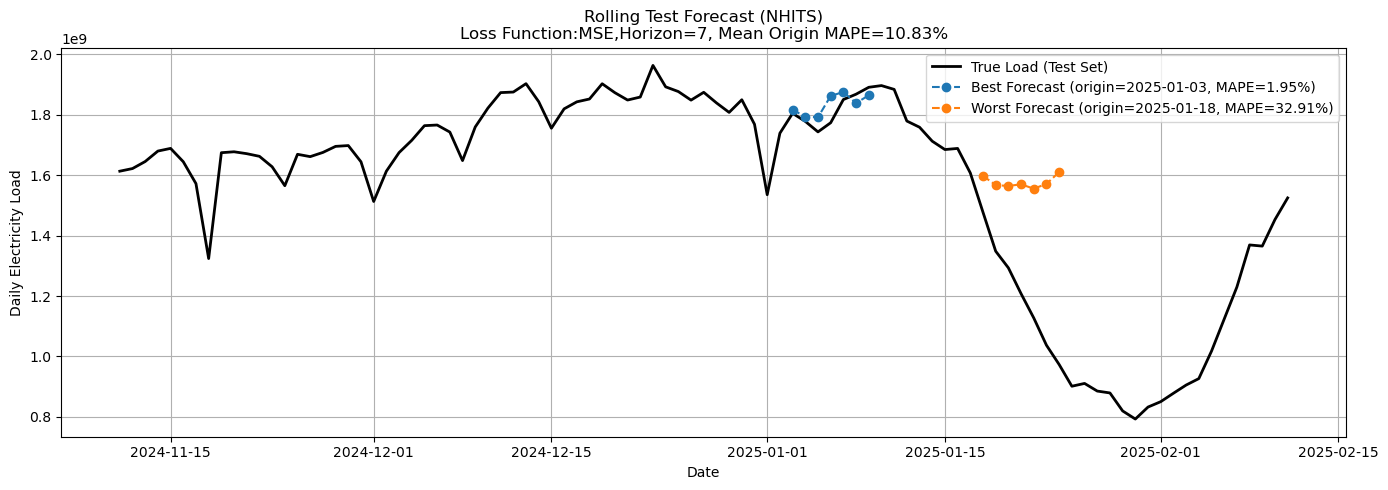

{'model_name': 'NHITS', 'val_overall_mape': 10.89513003615908, 'overall_mape': 10.832990500427941, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\NHITS_feat\\20260410_113601', 'best_model_path': 'artifacts\\NHITS_feat\\20260410_113601\\checkpoints\\final.ckpt', 'rolling_raw_path': 'artifacts\\NHITS_feat\\20260410_113601\\rolling_test_raw.csv'}
rolling_raw_path: artifacts\NHITS_feat\20260410_113601\rolling_test_raw.csv


In [3]:
from neuralforecast.models import NHITS

nhits_spec = ModelSpec(
    name='NHITS',
    model_type='neural',
    model_cls=NHITS,
    model_params={
        'max_steps': 100,
        'learning_rate': 1e-3,
        'scaler_type': 'standard',
    },
    supports_future_exog=True,
)

nhits_result = runner.run(nhits_spec)
print(nhits_result.summary())
print(f"rolling_raw_path: {nhits_result.rolling_raw_path}")


Seed set to 2026
Seed set to 2026


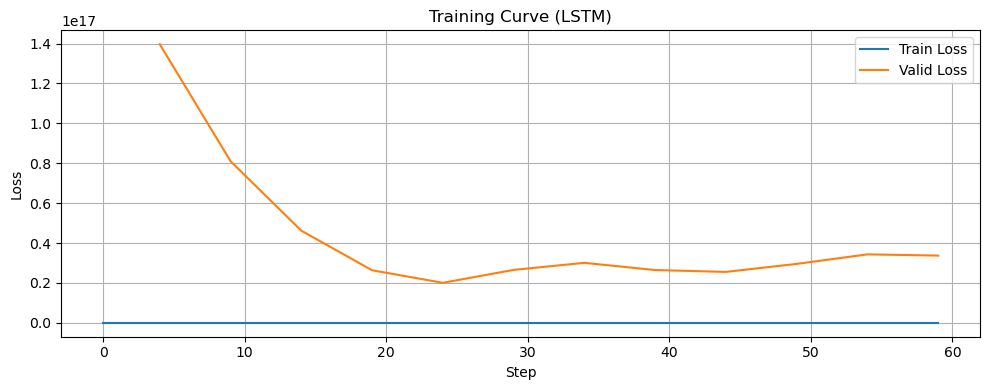

Seed set to 2026


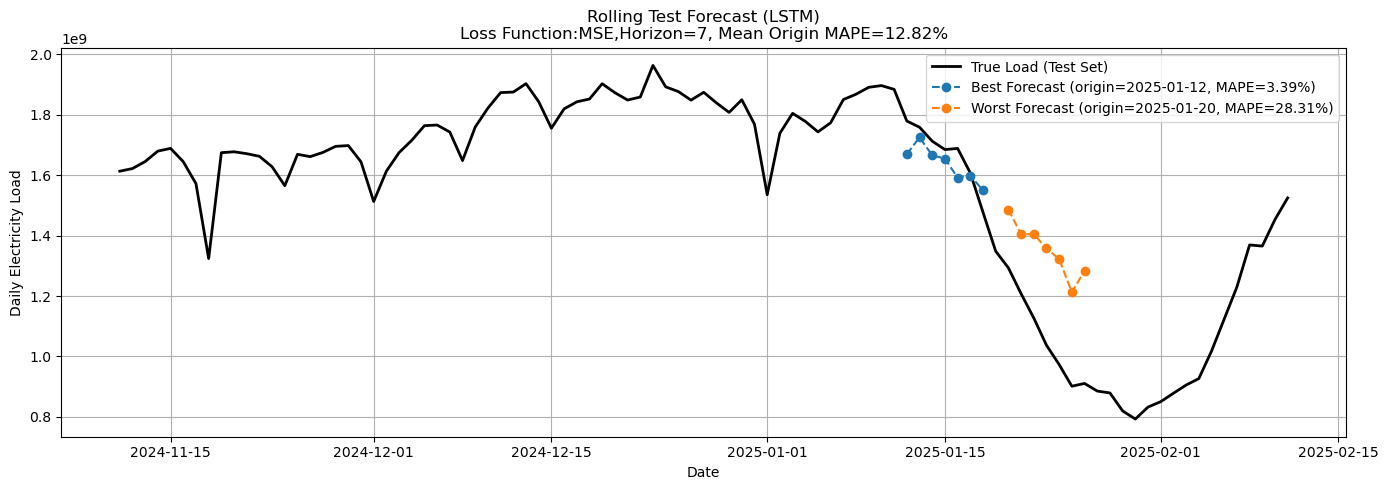

{'model_name': 'LSTM', 'val_overall_mape': 9.741967154612773, 'overall_mape': 12.823762796998448, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\LSTM_feat\\20260410_114002', 'best_model_path': 'artifacts\\LSTM_feat\\20260410_114002\\checkpoints\\final.ckpt', 'rolling_raw_path': 'artifacts\\LSTM_feat\\20260410_114002\\rolling_test_raw.csv'}
rolling_raw_path: artifacts\LSTM_feat\20260410_114002\rolling_test_raw.csv


In [3]:
from neuralforecast.models import LSTM

lstm_spec = ModelSpec(
    name='LSTM',
    model_type='neural',
    model_cls=LSTM,
    model_params={
        'encoder_hidden_size': 64,
        'encoder_n_layers': 2,
        'encoder_dropout': 0.1,
        'decoder_hidden_size': 64,
        'decoder_layers': 2,
        'max_steps': 100,
        'learning_rate': 1e-3,
        'scaler_type': 'standard',
    },
    supports_future_exog=True,
)

lstm_result = runner.run(lstm_spec)
print(lstm_result.summary())
print(f"rolling_raw_path: {lstm_result.rolling_raw_path}")


Seed set to 2026


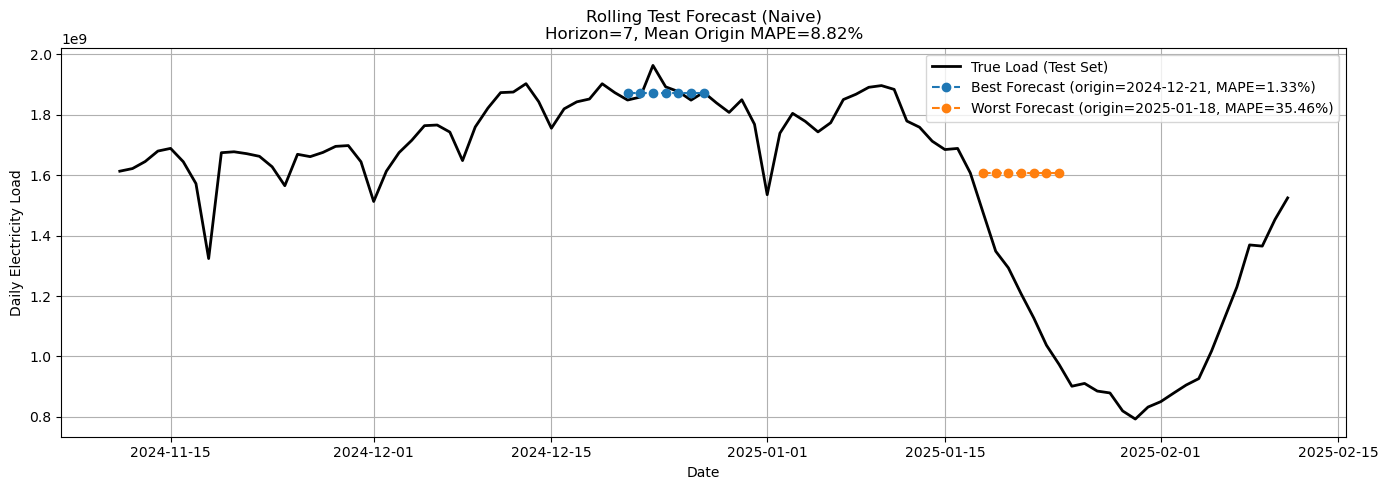

{'model_name': 'Naive', 'val_overall_mape': 7.798298665691358, 'overall_mape': 8.820472000008197, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\Naive_no_feat\\20260410_114020', 'best_model_path': None, 'rolling_raw_path': 'artifacts\\Naive_no_feat\\20260410_114020\\rolling_test_raw.csv'}
rolling_raw_path: artifacts\Naive_no_feat\20260410_114020\rolling_test_raw.csv


In [4]:
from statsforecast.models import Naive

naive_spec = ModelSpec(
    name='Naive',
    model_type='stats',
    model_cls=Naive,
    model_params={},
)

naive_result = runner.run(naive_spec)
print(naive_result.summary())
print(f"rolling_raw_path: {naive_result.rolling_raw_path}")


In [13]:
from neuralforecast.models import PatchTST

patchtst_spec = ModelSpec(
    name='PatchTST',
    model_type='neural',
    model_cls=PatchTST,
    model_params={
        'n_heads': 4,
        'hidden_size': 128,
        'dropout': 0.1,
        'max_steps': 100,
        'learning_rate': 1e-3,
    },
    supports_future_exog=False,
)

patchtst_result = runner.run(patchtst_spec)
print(patchtst_result.summary())
print(f"rolling_raw_path: {patchtst_result.rolling_raw_path}")


{'model_name': 'PatchTST', 'val_overall_mape': nan, 'overall_mape': nan, 'skipped': True, 'skip_reason': 'PatchTST does not support future exogenous variables while RunConfig.use_exog=True.', 'artifact_dir': None, 'best_model_path': None, 'rolling_raw_path': None}
rolling_raw_path: None


In [14]:
# from lightgbm import LGBMRegressor

# lgbm_spec = ModelSpec(
#     name='LGBMRegressor',
#     model_type='ml',
#     model_cls=LGBMRegressor,
#     model_params={
#         'n_estimators': 200,
#         'random_state': RANDOM_SEED,
#     },
#     supports_future_exog=True,
# )

# lgbm_result = runner.run(lgbm_spec)
# print(lgbm_result.summary())
# print(f"rolling_raw_path: {lgbm_result.rolling_raw_path}")
